In [1]:
import torch

In [2]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [4]:
import os

dot_path = r"G:\anaconda3\envs\neural_networks\Library\bin\dot.exe"

os.environ["PATH"] = r"G:\anaconda3\envs\neural_networks\Library\bin;" + os.environ["PATH"]
os.environ["GRAPHVIZ_DOT"] = dot_path

In [5]:
import graphviz.backend as be

def patched_run(cmd, *args, **kwargs):
    cmd[0] = cmd[0].replace("dot.bat", "dot.exe")
    return be.run.__wrapped__(cmd, *args, **kwargs)

be.run = patched_run

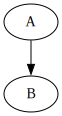

In [6]:
from graphviz import Digraph

g = Digraph()
g.edge("A", "B")
g

In [7]:
import graphviz.backend.execute as exe

exe._engine = None
exe._format = None

In [8]:
import graphviz.backend as be
be.EXECUTABLES = None

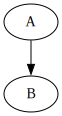

In [9]:
from graphviz import Digraph

g = Digraph(engine="dot")
g.edge("A", "B")
g

In [10]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("------")
print("X2",x2.grad.item())
print("W2",w2.grad.item())
print("X1",x1.grad.item())
print("W1",w1.grad.item())


0.7071066904050358
------
X2 0.5000001283844369
W2 0.0
X1 -1.5000003851533106
W1 1.0000002567688737


In [ ]:
import random
import math
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)   
        out = act.tanh()
        return out
    def parameters(self):
        return self.w +[self.b]
       
class Layer:

    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    


Value(data=-0.5865239655486959)

In [116]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=-0.37021016065037243)

In [117]:
n.parameters()

[Value(data=-0.26193501913382056),
 Value(data=-0.5153757309645934),
 Value(data=0.23564610868852753),
 Value(data=0.5903679210210206),
 Value(data=0.472535652826618),
 Value(data=-0.4280834672913867),
 Value(data=0.4237129703933109),
 Value(data=0.5428194639838293),
 Value(data=0.39531219741117507),
 Value(data=-0.15428077533167417),
 Value(data=-0.9490787607129734),
 Value(data=-0.732784789855712),
 Value(data=0.8403465666769472),
 Value(data=-0.23872816344560066),
 Value(data=0.43840757932663377),
 Value(data=0.043491685052678086),
 Value(data=0.013804845733969673),
 Value(data=0.2663527059793769),
 Value(data=0.3245651731656918),
 Value(data=0.18099027719754224),
 Value(data=0.0616718891848691),
 Value(data=0.2944517317389235),
 Value(data=-0.8986655925196732),
 Value(data=0.7839990502819898),
 Value(data=-0.8791268100023635),
 Value(data=0.3534029640723346),
 Value(data=0.9841626895681914),
 Value(data=-0.523477550024422),
 Value(data=-0.4047026463419994),
 Value(data=0.4441909556

In [118]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys = [1.0,-1.0,-1.0,1.0] # desired target


In [140]:
for k in range(20):
    ypred = [n(x) for x in xs]
    loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys,ypred)])
    
    ## backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data+=-0.05 * p.grad
    
    print(k,loss.data)
    
    



0 0.00261472362545883
1 0.0026008527934450925
2 0.002587124927853203
3 0.002573537851016102
4 0.0025600894290297056
5 0.0025467775706628695
6 0.0025336002262999237
7 0.002520555386914195
8 0.002507641083071772
9 0.0024948553839644234
10 0.002482196396470595
11 0.0024696622642436557
12 0.0024572511668263593
13 0.0024449613187907857
14 0.0024327909689027217
15 0.0024207383993099197
16 0.0024088019247531997
17 0.0023969798917998757
18 0.002385270678098489
19 0.0023736726916545998


In [ ]:
ypred

[Value(data=0.9784888618610114),
 Value(data=-0.9848082349011338),
 Value(data=-0.9735585172375928),
 Value(data=0.9686790502997412)]